(user_guide_custom_ga)=

# Building a Custom Genetic Algorithm

📖 {ref}`Optimization API Reference <api_optimization>`.

This notebook walks through the process of writing a custom genetic algorithm on top of `sigmaepsilon.math.optimize`, reusing as much of the library's infrastructure as possible. {py:class}`~sigmaepsilon.math.optimize.bga.BinaryGeneticAlgorithm`, {py:class}`~sigmaepsilon.math.optimize.iga.IntegerGeneticAlgorithm` and {py:class}`~sigmaepsilon.math.optimize.rga.RealValuedGeneticAlgorithm` (all covered in the {doc}`Optimization <index>` guide) are themselves nothing more than examples of exactly this process — small subclasses of {py:class}`~sigmaepsilon.math.optimize.ga.GeneticAlgorithm` that plug in a specific genotype representation. By the end of this notebook you'll have written a fourth one from scratch, and understand precisely which parts of the framework you get for free and which parts are genuinely yours to design.

## Why do we need a *custom* class here?

The three built-in classes all assume the decision variables are **independent**: each one lives in its own box (`ranges[d]`), and crossover/mutation can touch one variable without affecting the validity of the others. That covers a huge range of problems, but not all of them.

As a running example, we'll solve a small [Traveling Salesman Problem](https://en.wikipedia.org/wiki/Travelling_salesman_problem) (TSP): given a set of cities, find the shortest closed tour that visits every city exactly once. The natural representation for a candidate solution is a **permutation** of city indices — and permutations are exactly the case the box-independent assumption breaks down: if you mutate or crossover each position independently (the way {py:class}`~sigmaepsilon.math.optimize.bga.BinaryGeneticAlgorithm`/{py:class}`~sigmaepsilon.math.optimize.iga.IntegerGeneticAlgorithm`/{py:class}`~sigmaepsilon.math.optimize.rga.RealValuedGeneticAlgorithm` do), you'll almost certainly end up with a city missing and another one repeated — not a valid tour at all. We need crossover and mutation operators that are aware of the permutation constraint, which means writing our own {py:class}`~sigmaepsilon.math.optimize.ga.GeneticAlgorithm` subclass.

## The extension points, recapped

{py:class}`~sigmaepsilon.math.optimize.ga.GeneticAlgorithm` is built as a template-method: the evolution loop itself (`evolver`/`evolve`/`solve`, elitism, champion tracking, stopping) is fixed, and a subclass plugs in the representation-specific pieces:

| method | role | default in `GeneticAlgorithm` |
|---|---|---|
| `populate` | produce a pool of genotypes | raises `NotImplementedError` — must override |
| `crossover` | combine two parents into two offspring | raises `NotImplementedError` — must override |
| `mutate` | perturb one genotype | raises `NotImplementedError` — must override |
| `encode` / `decode` | genotype &#8596; phenotype | identity — override only if they differ |
| `select` | pick the survivors of a generation | pluggable, backed by `selection_strategy` — usually left alone |
| `stopping_criteria` | decide when to stop early | "champion age exceeds `maxage`" — override for a different rule |

For our permutation GA, `populate`/`crossover`/`mutate` are genuinely new (that's the whole point), while `encode`/`decode`/`select`/`stopping_criteria` — plus a good deal of bookkeeping in `__init__` (population-size validation, `elitism`, the per-instance `rng`, `selection_strategy`, `vectorized`/`n_jobs` evaluation) — can be reused as-is.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sigmaepsilon.math.optimize.ga import GeneticAlgorithm
from sigmaepsilon.math.optimize import RankSelection

## Step 0 — Define the problem

A handful of randomly placed cities, and the objective function: the total length of the closed tour that visits them in the order given by `order` (an array of city indices).

In [2]:
city_rng = np.random.default_rng(42)
n_cities = 15
coords = city_rng.uniform(0, 100, size=(n_cities, 2))


def tour_length(order):
    order = np.asarray(order, dtype=int)
    points = coords[order]
    points_next = np.roll(points, -1, axis=0)
    return np.sum(np.linalg.norm(points - points_next, axis=1))

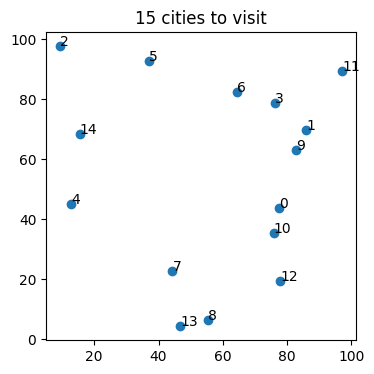

In [3]:
plt.figure(figsize=(4, 4))
plt.scatter(coords[:, 0], coords[:, 1])
for i, (x, y) in enumerate(coords):
    plt.annotate(str(i), (x, y))
plt.title(f"{n_cities} cities to visit")
plt.show()

We'll minimize `tour_length`, so every GA instance below is constructed with `minimize=True`.

## Step 1 — Subclass `GeneticAlgorithm` and adapt `__init__`

{py:class}`~sigmaepsilon.math.optimize.ga.GeneticAlgorithm`'s constructor takes `(fnc, ranges, *, ...)`, and uses `ranges` for two things: deriving `self.dim` (`self.ranges.shape[0]`, unless `fnc` has a `.dimension` attribute) and — in the built-in subclasses — scaling decoded values into a box. Our permutation problem has neither continuous ranges nor independent variables, but we still want `self.dim` to come out as the number of cities, so we accept `n_cities` directly and synthesize a placeholder `ranges` purely to get `self.dim` right; nothing in our GA will actually read the bounds inside it. Everything else — `nPop`, `elitism`, `seed`, `selection_strategy`, `vectorized`, `n_jobs`, ... — is simply forwarded to {py:class}`~sigmaepsilon.math.optimize.ga.GeneticAlgorithm`'s `__init__` via `**kwargs`, unchanged.

In [4]:
class PermutationGeneticAlgorithm(GeneticAlgorithm):
    __slots__ = ()

    def __init__(self, fnc, n_cities, **kwargs):
        placeholder_ranges = [[0, n_cities - 1]] * n_cities
        super().__init__(fnc, placeholder_ranges, **kwargs)

Before we implement `populate`/`crossover`/`mutate`, let's confirm the base class's contract really is enforced: constructing an instance calls `reset()`, which eagerly calls `populate()` to build the first generation, so instantiating now should fail loudly rather than silently doing nothing:

In [5]:
try:
    PermutationGeneticAlgorithm(tour_length, n_cities, nPop=8)
except NotImplementedError as e:
    print("Fails as expected:", e)

Fails as expected: PermutationGeneticAlgorithm does not implement 'populate'.


## Step 2 — `populate`

`populate(genotypes=None)` has two responsibilities, following the same pattern as {py:class}`~sigmaepsilon.math.optimize.bga.BinaryGeneticAlgorithm`/{py:class}`~sigmaepsilon.math.optimize.rga.RealValuedGeneticAlgorithm`:

- if `genotypes is None` (the very first generation), create `nPop / 2` random genotypes — here, random permutations of `range(n_cities)` via `self.rng.permutation`;
- otherwise, `genotypes` are the `nPop / 2` survivors returned by `select()`, and we need to breed them back up to a full population of `nPop` via `random_parents_generator` (inherited, unchanged) and our own `crossover`.

One subtlety worth calling out explicitly: {py:class}`~sigmaepsilon.math.optimize.ga.GeneticAlgorithm`'s `select` (which we are about to reuse unmodified) always returns `dtype=float`, since it was written with continuous phenotypes in mind. Our genotypes must stay integer city indices, so `populate` casts back to `int` right at the top.

In [6]:
def populate(self, genotypes=None):
    nPop = self.nPop

    if genotypes is None:
        genotypes = np.array(
            [self.rng.permutation(self.dim) for _ in range(int(nPop / 2))]
        )
    else:
        genotypes = np.asarray(genotypes, dtype=int)

    nParent = genotypes.shape[0]

    if nParent < nPop:
        offspring = []
        parent_pairs = self.random_parents_generator(genotypes)
        while (len(offspring) + nParent) < nPop:
            parent1, parent2 = next(parent_pairs)
            offspring.extend(self.crossover(parent1, parent2))
        genotypes = np.vstack([genotypes, offspring])

    return genotypes


PermutationGeneticAlgorithm.populate = populate

## Step 3 — `crossover`

Naive crossover (e.g. cutting both parents at the same point and swapping halves, like {py:class}`~sigmaepsilon.math.optimize.bga.BinaryGeneticAlgorithm` does) would produce invalid tours: a city could appear twice in the child and another not at all. We need an operator that's aware of the permutation constraint — the classic choice is **order crossover (OX)**:

1. pick two random cut points and copy the slice between them from parent 1 into the child, unchanged;
2. fill the remaining positions, in the order they appear in parent 2, skipping any city that's already in the copied slice.

This guarantees the child is a valid permutation, while still inheriting structure from both parents. We build both children (swapping the parents' roles) and immediately hand each one to `mutate` — mirroring exactly the shape of {py:class}`~sigmaepsilon.math.optimize.bga.BinaryGeneticAlgorithm`'s `crossover`.

In [7]:
def crossover(self, parent1, parent2):
    n = self.dim

    if self.rng.random() > self.p_c:
        return parent1.copy(), parent2.copy()

    i, j = sorted(self.rng.choice(n, size=2, replace=False))

    def order_crossover(donor, filler):
        child = -np.ones(n, dtype=int)
        child[i:j] = donor[i:j]
        remaining = [city for city in filler if city not in child[i:j]]
        child[child == -1] = remaining
        return child

    child1 = order_crossover(parent1, parent2)
    child2 = order_crossover(parent2, parent1)
    return self.mutate(child1), self.mutate(child2)


PermutationGeneticAlgorithm.crossover = crossover

## Step 4 — `mutate`

Similarly, mutating by flipping bits (as {py:class}`~sigmaepsilon.math.optimize.bga.BinaryGeneticAlgorithm` does) makes no sense for a permutation. The standard choice is **swap mutation**: with probability `p_m`, pick two positions and swap their cities. That's it — the result is trivially still a valid permutation.

In [8]:
def mutate(self, child):
    if self.rng.random() < self.p_m:
        child = child.copy()
        i, j = self.rng.choice(self.dim, size=2, replace=False)
        child[i], child[j] = child[j], child[i]
    return child


PermutationGeneticAlgorithm.mutate = mutate

With `mutate` in place too, we can finally instantiate the class (recall it failed above) and sanity-check `crossover`/`mutate` together, on two small, human-readable permutations, before trusting them inside a full GA run:

In [9]:
toy_ga = PermutationGeneticAlgorithm(lambda order: 0.0, 8, nPop=8, seed=0)
toy_parent1 = np.array([0, 1, 2, 3, 4, 5, 6, 7])
toy_parent2 = np.array([3, 7, 5, 1, 6, 0, 2, 4])

toy_child1, toy_child2 = toy_ga.crossover(toy_parent1, toy_parent2)
print("parent 1:", toy_parent1)
print("parent 2:", toy_parent2)
print("child 1: ", toy_child1)
print("child 2: ", toy_child2)
print("both children are valid permutations:", set(toy_child1) == set(toy_child2) == set(range(8)))

parent 1: [0 1 2 3 4 5 6 7]
parent 2: [3 7 5 1 6 0 2 4]
child 1:  [7 1 2 3 4 5 6 0]
child 2:  [2 7 5 1 6 0 3 4]
both children are valid permutations: True


## What we *didn't* have to write

With `populate`/`crossover`/`mutate` in place, the class is fully functional — everything else is inherited from {py:class}`~sigmaepsilon.math.optimize.ga.GeneticAlgorithm` untouched:

In [10]:
assert PermutationGeneticAlgorithm.encode is GeneticAlgorithm.encode
assert PermutationGeneticAlgorithm.decode is GeneticAlgorithm.decode
assert PermutationGeneticAlgorithm.select is GeneticAlgorithm.select
assert PermutationGeneticAlgorithm.divide is GeneticAlgorithm.divide
assert PermutationGeneticAlgorithm.stopping_criteria is GeneticAlgorithm.stopping_criteria
assert PermutationGeneticAlgorithm.random_parents_generator is GeneticAlgorithm.random_parents_generator
print("encode/decode/select/divide/stopping_criteria/random_parents_generator: all reused as-is")

encode/decode/select/divide/stopping_criteria/random_parents_generator: all reused as-is


`encode`/`decode` default to the identity mapping, which is exactly right here: our genotype (a permutation of city indices) already *is* the phenotype, the same way it is for {py:class}`~sigmaepsilon.math.optimize.rga.RealValuedGeneticAlgorithm`. `select` already comes with a working, pluggable implementation backed by `selection_strategy` (default {py:class}`~sigmaepsilon.math.optimize.selection.TournamentSelection`) — we'll make use of that pluggability further down. `stopping_criteria`'s default (stop once the champion hasn't improved for `maxage` generations) is a perfectly sensible rule for a TSP tour too.

## Solving the problem

Everything is in place — let's run it.

In [11]:
ga = PermutationGeneticAlgorithm(
    tour_length, n_cities, nPop=60, minimize=True, maxage=30, seed=0
)

fitness_history = []
diversity_history = []
for _ in range(120):
    ga.evolve(1)
    fitness_history.append(ga.champion.fitness)
    diversity_history.append(ga.diversity)

champion_order = np.asarray(ga.champion.phenotype, dtype=int)
print("best tour found:", champion_order)
print("tour length:", ga.champion.fitness)

best tour found: [ 4 14  2  5  6  0 10 12  8 13  7  9  1 11  3]
tour length: 410.03967346322673


For context, let's compare against the best of 2000 purely random tours:

In [12]:
random_lengths = [tour_length(city_rng.permutation(n_cities)) for _ in range(2000)]
print("best of 2000 random tours:", min(random_lengths))
print("GA champion:              ", ga.champion.fitness)

best of 2000 random tours: 551.051547282789
GA champion:               410.03967346322673


And visualize both the resulting tour and the convergence history — including the **inherited** `diversity` property, which works out of the box because it's computed generically from `self.phenotypes` (the per-dimension standard deviation across the population). It's not the most natural diversity measure for permutations, but it's still informative: a value near zero means the population has collapsed onto very similar orderings.

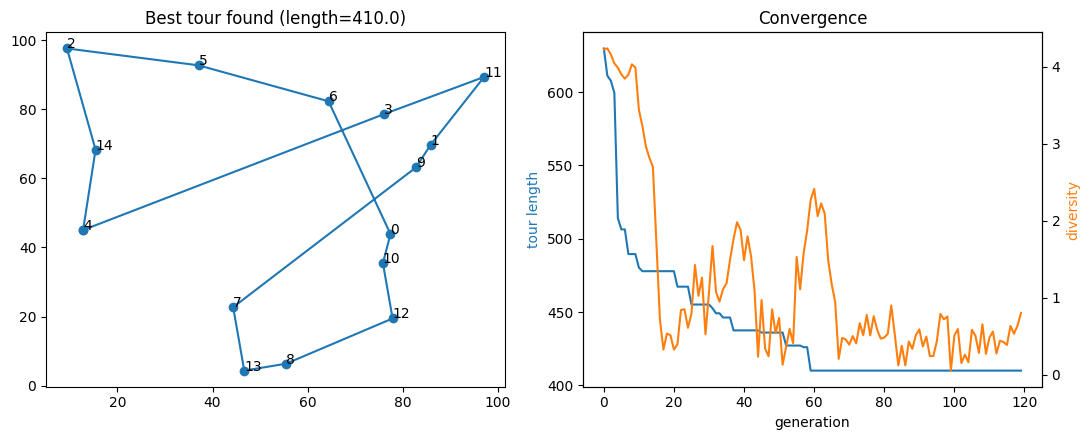

In [13]:
tour_points = coords[np.append(champion_order, champion_order[0])]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(tour_points[:, 0], tour_points[:, 1], "o-")
for i, (x, y) in enumerate(coords):
    axes[0].annotate(str(i), (x, y))
axes[0].set_title(f"Best tour found (length={ga.champion.fitness:.1f})")

axes[1].plot(fitness_history, color="tab:blue")
axes[1].set_xlabel("generation")
axes[1].set_ylabel("tour length", color="tab:blue")
ax2 = axes[1].twinx()
ax2.plot(diversity_history, color="tab:orange")
ax2.set_ylabel("diversity", color="tab:orange")
axes[1].set_title("Convergence")

plt.tight_layout()
plt.show()

## Reusing the library's pluggability

Because `select` was left untouched, our brand-new GA already supports every {py:class}`~sigmaepsilon.math.optimize.selection.SelectionStrategy` the library ships with — no extra code required. Let's rerun with {py:class}`~sigmaepsilon.math.optimize.selection.RankSelection` instead of the default {py:class}`~sigmaepsilon.math.optimize.selection.TournamentSelection`:

In [14]:
ga_rank = PermutationGeneticAlgorithm(
    tour_length,
    n_cities,
    nPop=60,
    minimize=True,
    maxage=30,
    seed=0,
    selection_strategy=RankSelection(),
)
champion_rank = ga_rank.solve()
print("TournamentSelection (default):", ga.champion.fitness)
print("RankSelection:                ", champion_rank.fitness)

TournamentSelection (default): 410.03967346322673
RankSelection:                 419.6873865767511


Reproducibility comes for free too, via the same `seed` argument every other GA class in the library accepts:

In [15]:
ga_a = PermutationGeneticAlgorithm(tour_length, n_cities, nPop=60, minimize=True, maxage=30, seed=7)
ga_b = PermutationGeneticAlgorithm(tour_length, n_cities, nPop=60, minimize=True, maxage=30, seed=7)
result_a = ga_a.solve()
result_b = ga_b.solve()
result_a.phenotype == result_b.phenotype

True

## Bonus: overriding a property — a permutation-aware diversity metric

The inherited `diversity` property (per-dimension standard deviation of the phenotypes) treats city indices as if they were numbers on a continuous scale, which isn't quite the right notion of "spread" for permutations. Since `diversity` is a regular `property`, we can override it just as easily as any method — here with the average, over all pairs of individuals, of the fraction of positions at which they disagree:

In [16]:
def diversity(self) -> float:
    genotypes = np.asarray(self.genotypes)
    disagreement = (genotypes[:, None, :] != genotypes[None, :, :]).mean(axis=2)
    i, j = np.triu_indices(len(genotypes), k=1)
    return float(disagreement[i, j].mean())


PermutationGeneticAlgorithm.diversity = property(diversity)

ga_custom_diversity = PermutationGeneticAlgorithm(
    tour_length, n_cities, nPop=60, minimize=True, maxage=30, seed=0
)
ga_custom_diversity.evolve(5)
ga_custom_diversity.diversity

0.8228625235404896

## Recap

Starting from {py:class}`~sigmaepsilon.math.optimize.ga.GeneticAlgorithm`, a working, reproducible, pluggable-selection genetic algorithm for a genuinely different genotype representation (permutations, not independent boxed variables) took:

- a thin `__init__` override to adapt the constructor's shape to the problem at hand;
- `populate`, `crossover` (order crossover) and `mutate` (swap mutation) — the three methods with no meaningful generic default, exactly as the base class's docstring says;
- optionally, a `diversity` override for a representation-specific notion of population spread.

Everything else — population-size validation, `elitism`, the per-instance `rng` (and therefore `seed`-based reproducibility), `selection_strategy` (and therefore {py:class}`~sigmaepsilon.math.optimize.selection.TournamentSelection`/{py:class}`~sigmaepsilon.math.optimize.selection.RouletteSelection`/{py:class}`~sigmaepsilon.math.optimize.selection.RankSelection` for free), `vectorized`/`n_jobs` evaluation, champion tracking, `stopping_criteria`, and the whole `evolver`/`evolve`/`solve` loop — came from {py:class}`~sigmaepsilon.math.optimize.ga.GeneticAlgorithm` unmodified. This is exactly the same recipe {py:class}`~sigmaepsilon.math.optimize.bga.BinaryGeneticAlgorithm`, {py:class}`~sigmaepsilon.math.optimize.iga.IntegerGeneticAlgorithm` and {py:class}`~sigmaepsilon.math.optimize.rga.RealValuedGeneticAlgorithm` follow internally; see their source (`sigmaepsilon/math/optimize/{bga,iga,rga}.py`) for two more worked examples of the same pattern.

📖 {ref}`Genetic Algorithms API Reference <api_optimization_GA>`.